<center><h1>Students' Social Media Addiction</h1></center>

In [1]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

## Data loading

In [2]:
# Download latest version
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")

print("Path to dataset files:", path)

# Download dataset
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")

# Load the CSV file
files = os.listdir(path)
print(files)  

df = pd.read_csv(f"{path}/{files[0]}") 
df.head(-5)

Path to dataset files: /Users/christos/.cache/kagglehub/datasets/adilshamim8/social-media-addiction-vs-relationships/versions/3
['Students Social Media Addiction.csv']


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,696,23,Male,Graduate,USA,5.5,Twitter,Yes,6.7,6,In Relationship,3,7
696,697,21,Female,Undergraduate,Mexico,6.3,TikTok,Yes,6.2,5,Single,4,8
697,698,24,Male,Graduate,France,4.8,Facebook,No,7.1,7,In Relationship,2,5
698,699,19,Female,Undergraduate,Canada,5.7,Instagram,Yes,6.6,6,Single,3,7


## Quality Control

In [3]:
# ============================================================
# 1. BASIC DATASET INFO
# ============================================================
print("="*50)
print("BASIC INFO")
print("="*50)
print(f"Total rows        : {df.shape[0]}")
print(f"Total columns     : {df.shape[1]}")
print(f"Numerical columns : {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")

# ============================================================
# 2. MISSING VALUES
# ============================================================
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# ============================================================
# 3. DUPLICATES
# ============================================================
print("\n" + "="*50)
print("DUPLICATES")
print("="*50)
print(f"Duplicate rows     : {df.duplicated().sum()}")
print(f"Duplicate IDs      : {df['Student_ID'].duplicated().sum()}")

# ============================================================
# 4. CARDINALITY (unique values per column)
# ============================================================
print("\n" + "="*50)
print("CARDINALITY (unique values per column)")
print("="*50)
for col in df.columns:
    print(f"{col:<35}: {df[col].nunique()} unique values")

# ============================================================
# 5. NUMERICAL SUMMARY (beyond describe)
# ============================================================
print("\n" + "="*50)
print("NUMERICAL SUMMARY")
print("="*50)
numerical_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                  'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']

summary_stats = pd.DataFrame({
    'Mean'    : df[numerical_cols].mean().round(2),
    'Median'  : df[numerical_cols].median().round(2),
    'Std'     : df[numerical_cols].std().round(2),
    'Min'     : df[numerical_cols].min(),
    'Max'     : df[numerical_cols].max(),
    'Skewness': df[numerical_cols].skew().round(2),
    'Kurtosis': df[numerical_cols].kurt().round(2),
    'IQR'     : (df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25)).round(2),
})
print(summary_stats)

# ============================================================
# 6. CATEGORICAL SUMMARY
# ============================================================
print("\n" + "="*50)
print("CATEGORICAL SUMMARY")
print("="*50)
categorical_cols = ['Gender', 'Academic_Level', 'Most_Used_Platform',
                    'Affects_Academic_Performance', 'Relationship_Status']

for col in categorical_cols:
    print(f"\n{col}:")
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'Count': counts, 'Percentage(%)': pcts}))

# ============================================================
# 7. OUTLIER COUNT (using IQR method)
# ============================================================
print("\n" + "="*50)
print("OUTLIERS (IQR method)")
print("="*50)
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col:<35}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

# ============================================================
# 8. DATA TYPES
# ============================================================
print("\n" + "="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

BASIC INFO
Total rows        : 705
Total columns     : 13
Numerical columns : 7
Categorical columns: 6

MISSING VALUES
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

Total missing: 0

DUPLICATES
Duplicate rows     : 0
Duplicate IDs      : 0

CARDINALITY (unique values per column)
Student_ID                         : 705 unique values
Age                                : 7 unique values
Gender                             : 2 unique values
Academic_Level                     : 3 unique values
Country                            : 110 unique values
Avg_Daily_Usage_Hours              : 67 u

Value Ranges :

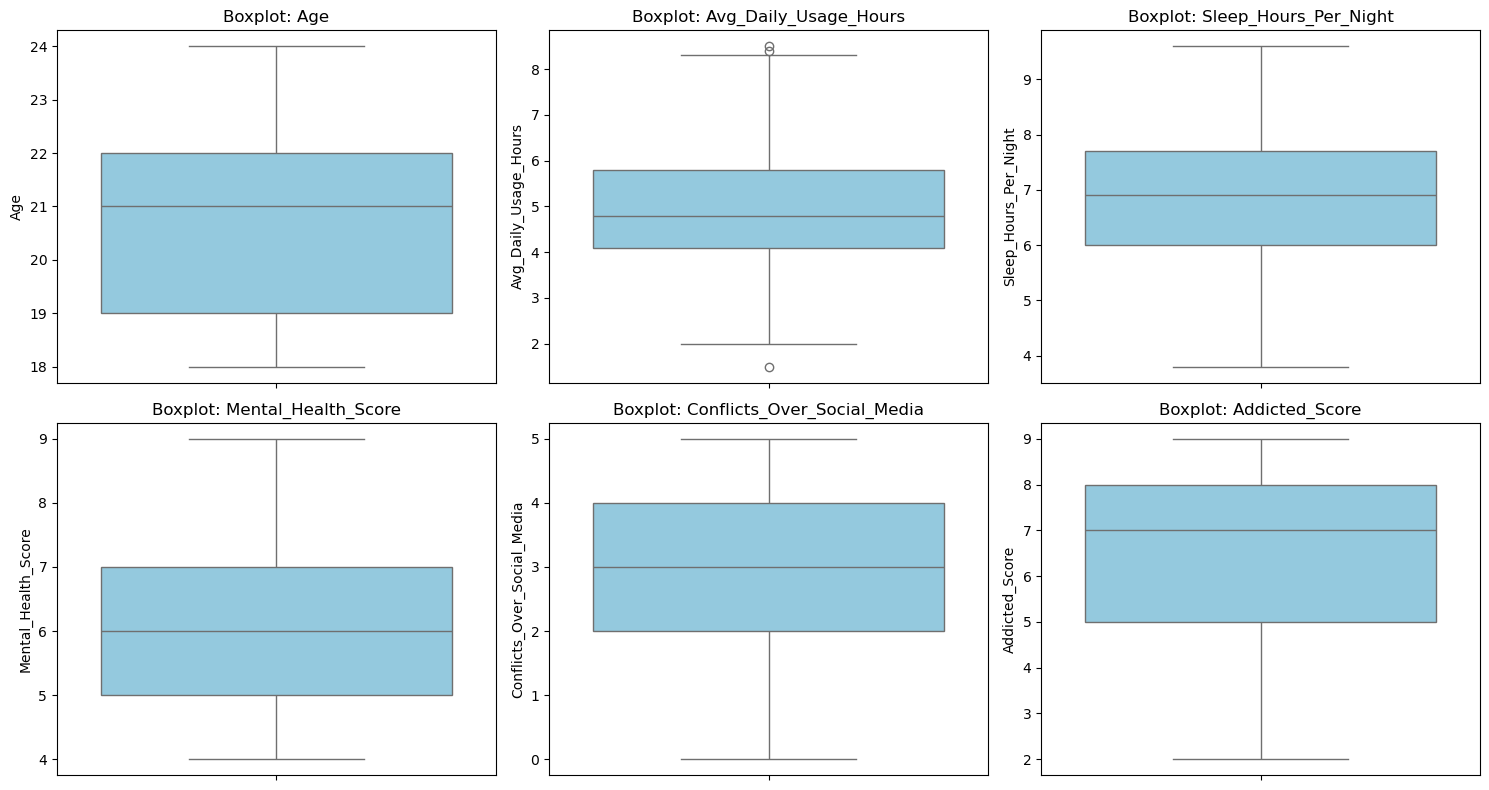

In [4]:
numerical_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 
                  'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

## Exploratory Data Analysis

Distribution of Numerical Variables :

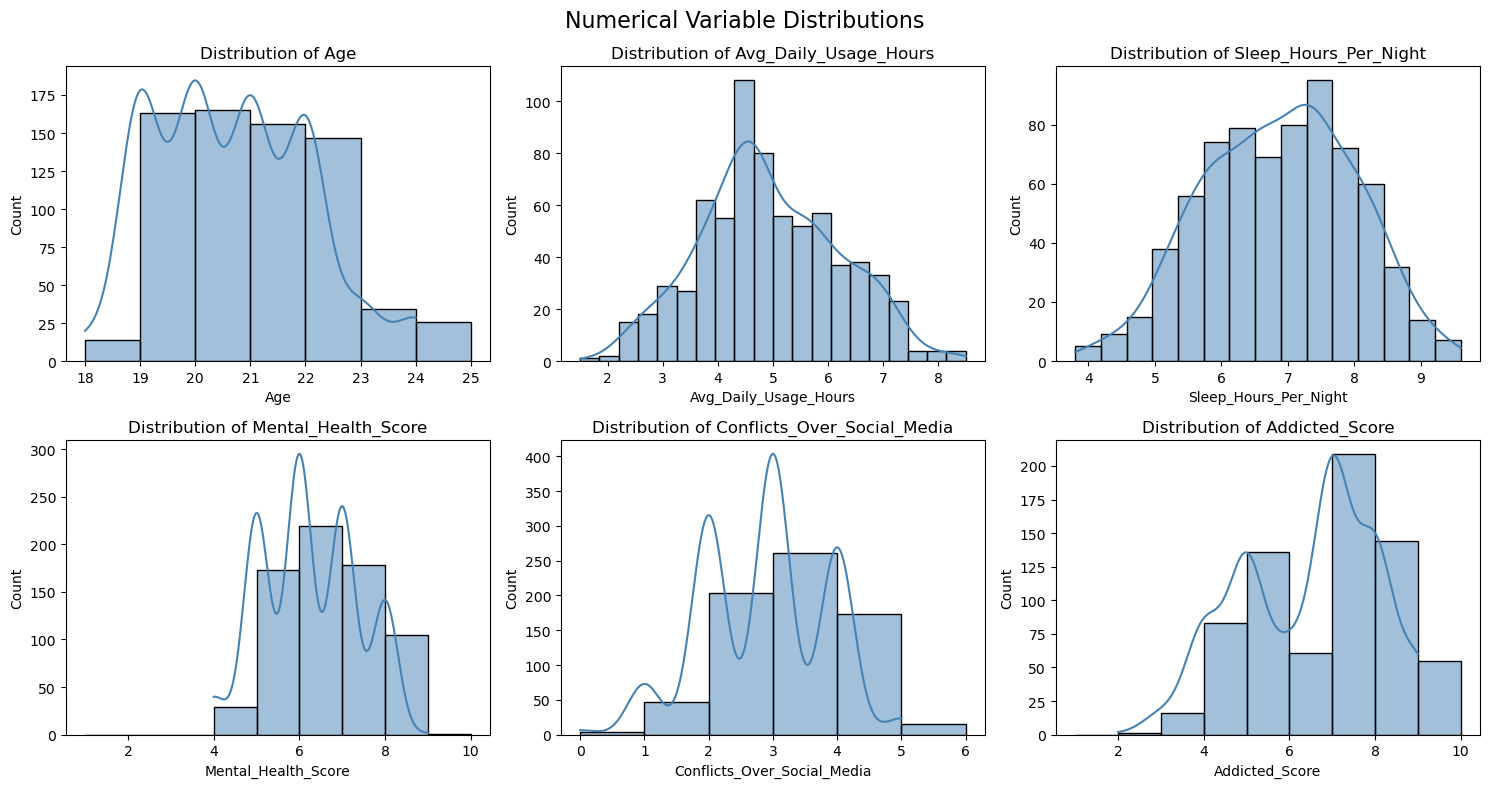

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

bins_dict = {
    'Age': range(18, 26, 1),
    'Avg_Daily_Usage_Hours': 20,
    'Sleep_Hours_Per_Night': 15,
    'Mental_Health_Score': range(1, 11, 1),
    'Conflicts_Over_Social_Media': range(0, 7, 1),
    'Addicted_Score': range(1, 11, 1)
}

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=bins_dict[col])
    axes[i].set_title(f'Distribution of {col}')

plt.suptitle("Numerical Variable Distributions", fontsize=16)
plt.tight_layout()
plt.show()

Distribution of Categorical Variables :

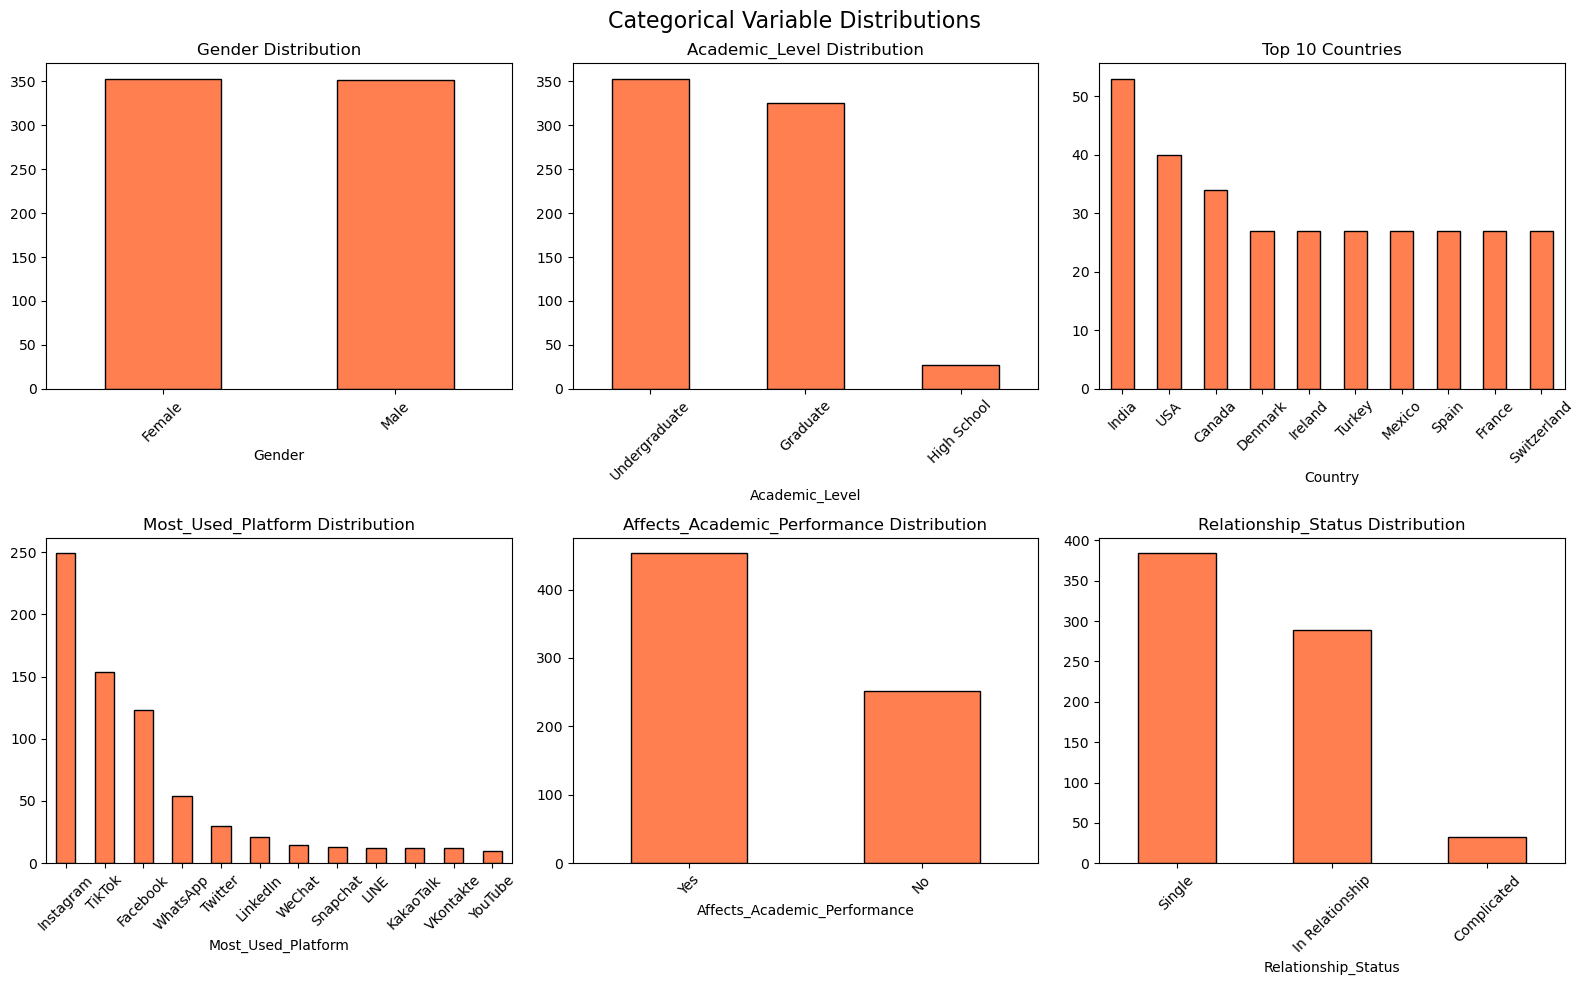

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

categorical_cols = ['Gender', 'Academic_Level', 'Country', 
                    'Most_Used_Platform', 'Affects_Academic_Performance', 
                    'Relationship_Status']

for i, col in enumerate(categorical_cols):
    if col == 'Country':
        # Only plot top 10 countries
        top10 = df[col].value_counts().head(10)
        top10.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title('Top 10 Countries')
    else:
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'{col} Distribution')
    
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Categorical Variable Distributions", fontsize=16)
plt.tight_layout()
plt.show()

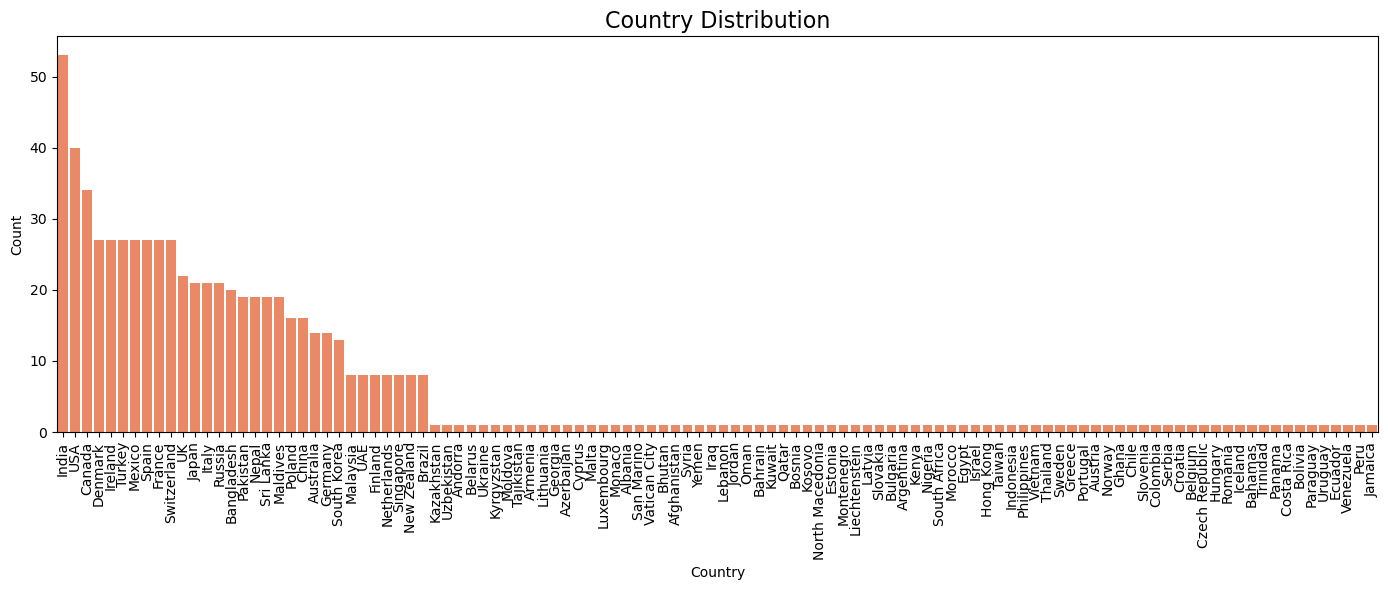

In [7]:
plt.figure(figsize=(14, 6))

country_counts = df['Country'].value_counts()

sns.barplot(x=country_counts.index, y=country_counts.values, color='coral')

plt.title("Country Distribution", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Correlation Heatmap :

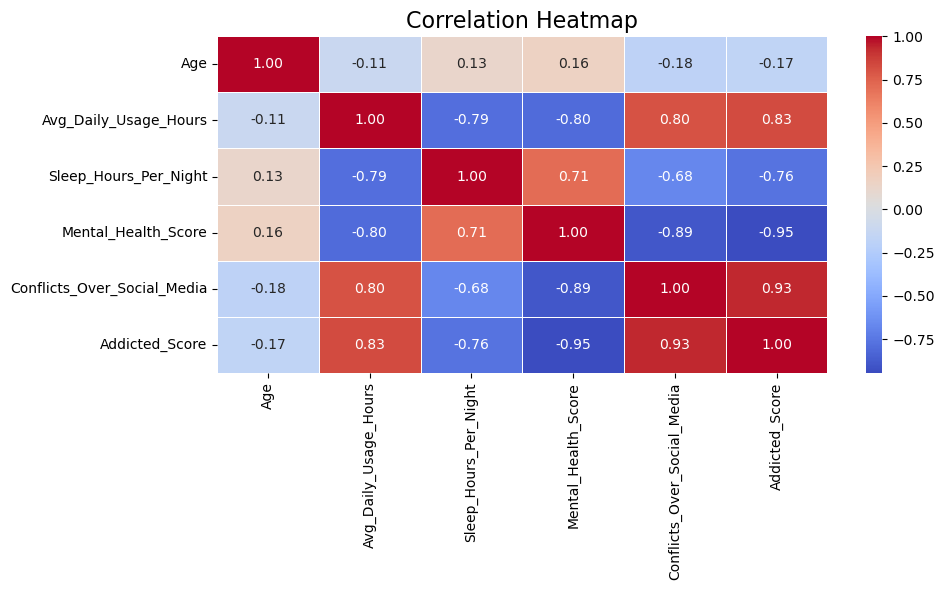

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
continent_map = {
    # Asia (34 countries)
    'Afghanistan': 'Asia', 'Armenia': 'Asia', 'Azerbaijan': 'Asia',
    'Bahrain': 'Asia', 'Bangladesh': 'Asia', 'Bhutan': 'Asia',
    'China': 'Asia', 'Hong Kong': 'Asia', 'India': 'Asia',
    'Indonesia': 'Asia', 'Iraq': 'Asia', 'Israel': 'Asia',
    'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia',
    'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Lebanon': 'Asia',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Nepal': 'Asia',
    'Oman': 'Asia', 'Pakistan': 'Asia', 'Philippines': 'Asia',
    'Qatar': 'Asia', 'Singapore': 'Asia', 'South Korea': 'Asia',
    'Sri Lanka': 'Asia', 'Syria': 'Asia', 'Taiwan': 'Asia',
    'Tajikistan': 'Asia', 'Thailand': 'Asia', 'Turkey': 'Asia',
    'UAE': 'Asia', 'Uzbekistan': 'Asia', 'Vietnam': 'Asia',
    'Yemen': 'Asia',

    # Europe (44 countries)
    'Albania': 'Europe', 'Andorra': 'Europe', 'Austria': 'Europe',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Bosnia': 'Europe',
    'Bulgaria': 'Europe', 'Croatia': 'Europe', 'Cyprus': 'Europe',
    'Czech Republic': 'Europe', 'Denmark': 'Europe', 'Estonia': 'Europe',
    'Finland': 'Europe', 'France': 'Europe', 'Georgia': 'Europe',
    'Germany': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe',
    'Iceland': 'Europe', 'Ireland': 'Europe', 'Italy': 'Europe',
    'Kosovo': 'Europe', 'Latvia': 'Europe', 'Liechtenstein': 'Europe',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe',
    'Moldova': 'Europe', 'Monaco': 'Europe', 'Montenegro': 'Europe',
    'Netherlands': 'Europe', 'North Macedonia': 'Europe', 'Norway': 'Europe',
    'Poland': 'Europe', 'Portugal': 'Europe', 'Romania': 'Europe',
    'Russia': 'Europe', 'San Marino': 'Europe', 'Serbia': 'Europe',
    'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'UK': 'Europe',
    'Ukraine': 'Europe', 'Vatican City': 'Europe',

    # Americas (16 countries)
    'Argentina': 'Americas', 'Bahamas': 'Americas', 'Bolivia': 'Americas',
    'Brazil': 'Americas', 'Canada': 'Americas', 'Chile': 'Americas',
    'Colombia': 'Americas', 'Costa Rica': 'Americas', 'Ecuador': 'Americas',
    'Jamaica': 'Americas', 'Mexico': 'Americas', 'Panama': 'Americas',
    'Paraguay': 'Americas', 'Peru': 'Americas', 'Trinidad': 'Americas',
    'Uruguay': 'Americas', 'USA': 'Americas', 'Venezuela': 'Americas',

    # Africa (6 countries)
    'Egypt': 'Africa', 'Ghana': 'Africa', 'Kenya': 'Africa',
    'Morocco': 'Africa', 'Nigeria': 'Africa', 'South Africa': 'Africa',

    # Oceania (2 countries)
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}

df['Continent'] = df['Country'].map(continent_map)

# Bin Avg_Daily_Usage_Hours by each hour
df['Usage_Category'] = pd.cut(df['Avg_Daily_Usage_Hours'],
                               bins=[1, 2, 3, 4, 5, 6, 7, 8, 9],
                               labels=['1-2h', '2-3h', '3-4h', '4-5h', 
                                       '5-6h', '6-7h', '7-8h', '8-9h'])

# Bin Sleep_Hours_Per_Night by each hour
df['Sleep_Category'] = pd.cut(df['Sleep_Hours_Per_Night'],
                               bins=[3, 4, 5, 6, 7, 8, 9, 10],
                               labels=['3-4h', '4-5h', '5-6h', '6-7h', 
                                       '7-8h', '8-9h', '9-10h'])

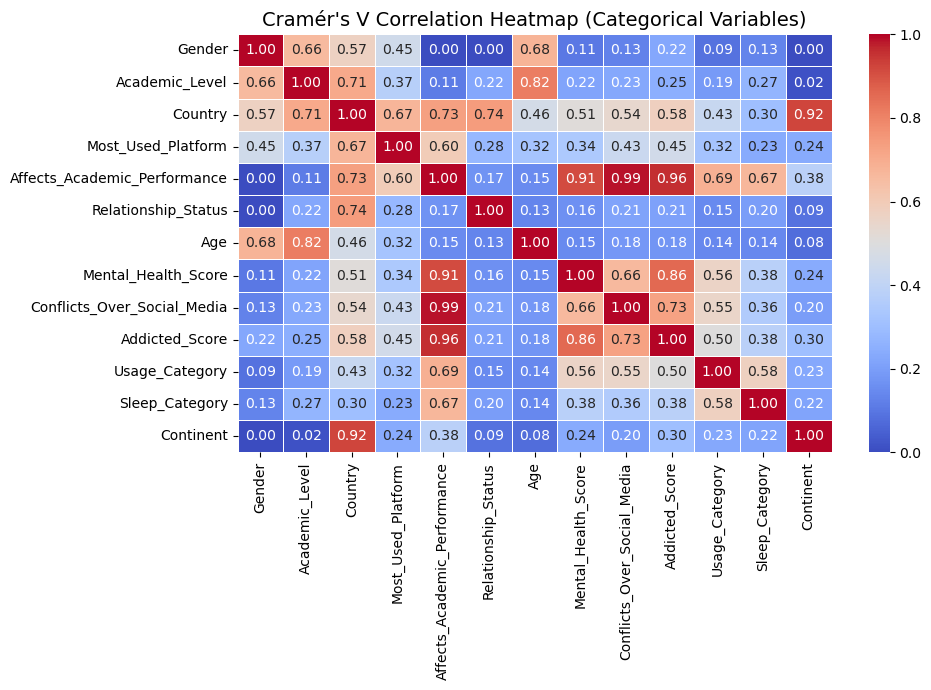

In [10]:
# Function to calculate Cramér's V between two columns
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select categorical columns
categorical_cols = ['Gender', 'Academic_Level', 'Country', 
                    'Most_Used_Platform', 'Affects_Academic_Performance', 
                    'Relationship_Status', "Age", 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score', 
                    'Usage_Category', 'Sleep_Category', 'Continent']

# Build correlation matrix
cramers_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cramers_matrix.astype(float), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5,
            vmin=0, vmax=1)

plt.title("Cramér's V Correlation Heatmap (Categorical Variables)", fontsize=14)
plt.tight_layout()
plt.show()

Pairplot (Overall Relationships) :

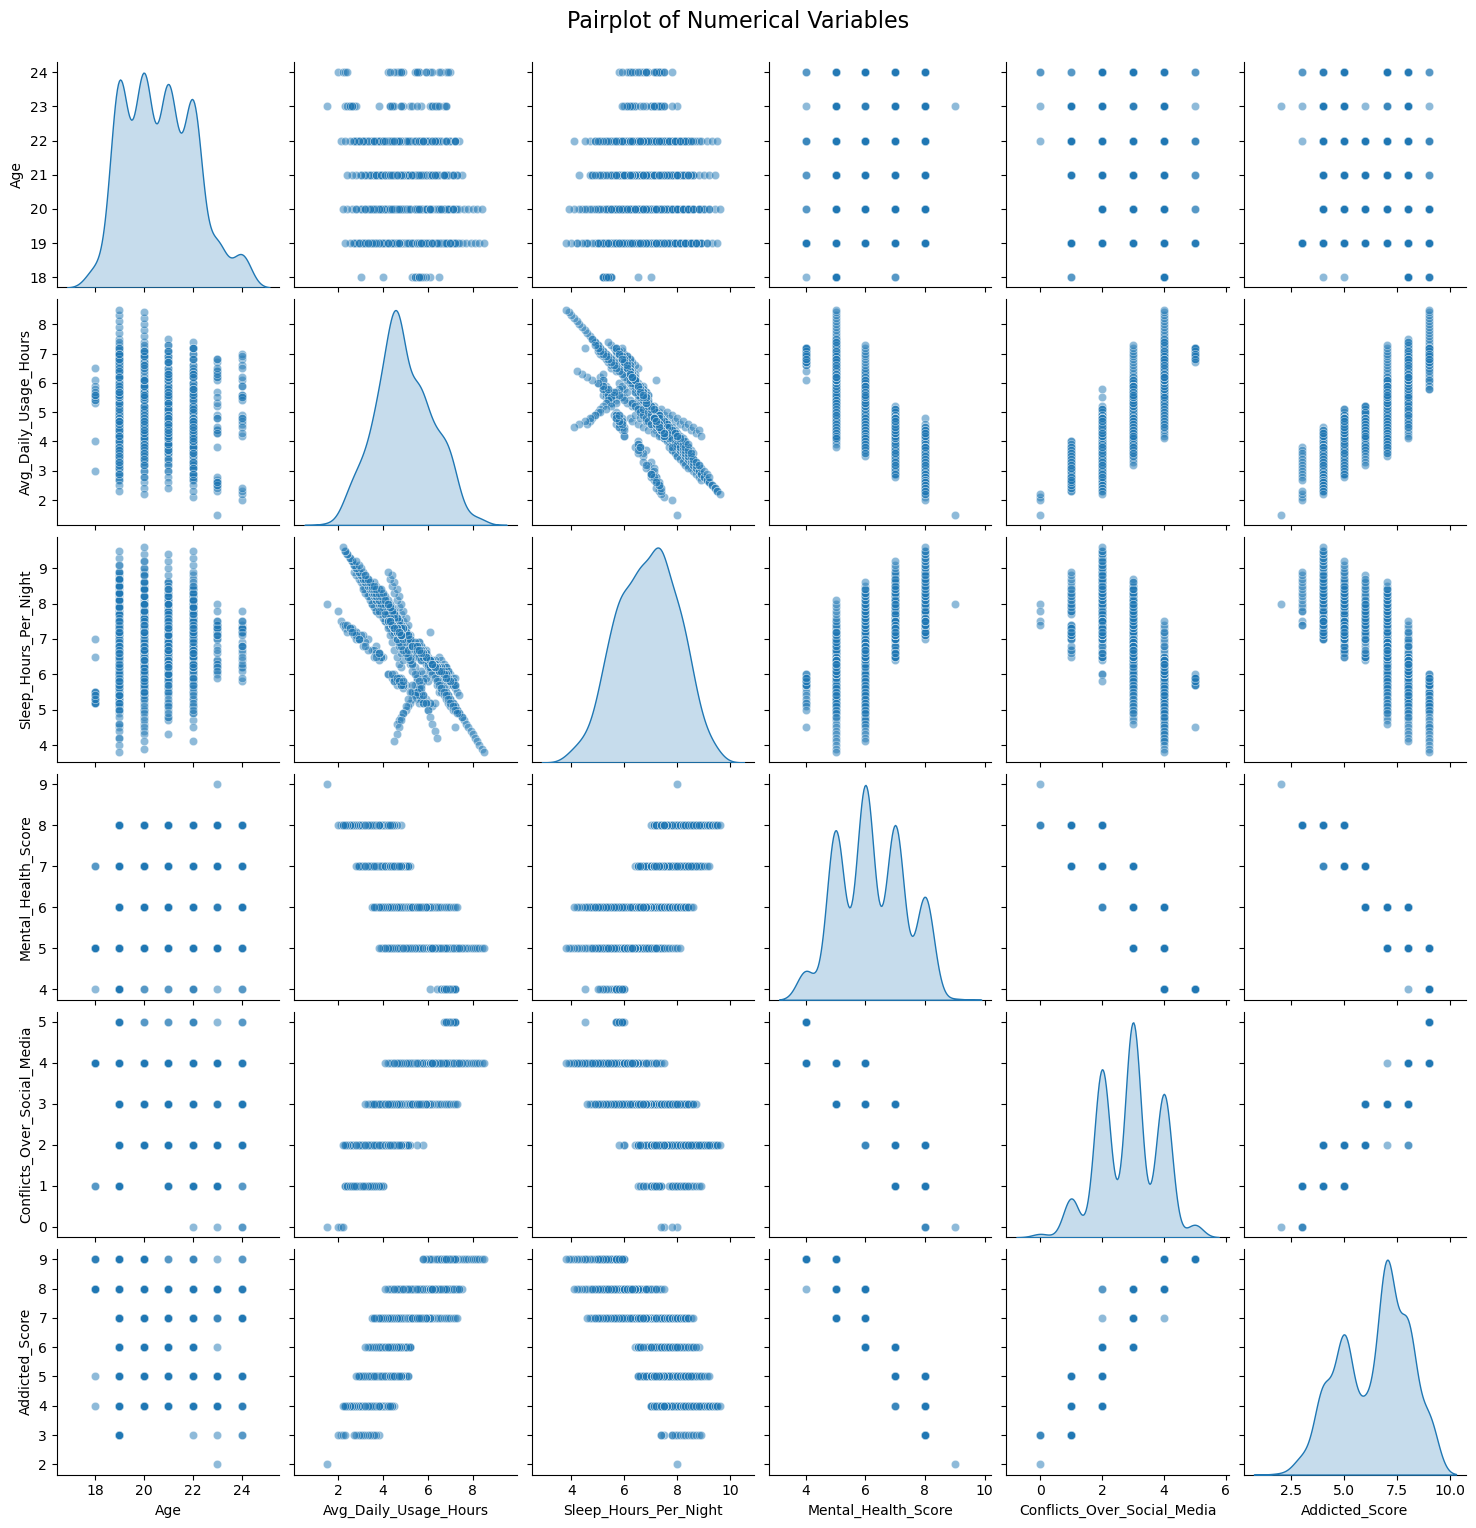

In [11]:
sns.pairplot(df[numerical_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot of Numerical Variables", y=1.02, fontsize=16)
plt.show()

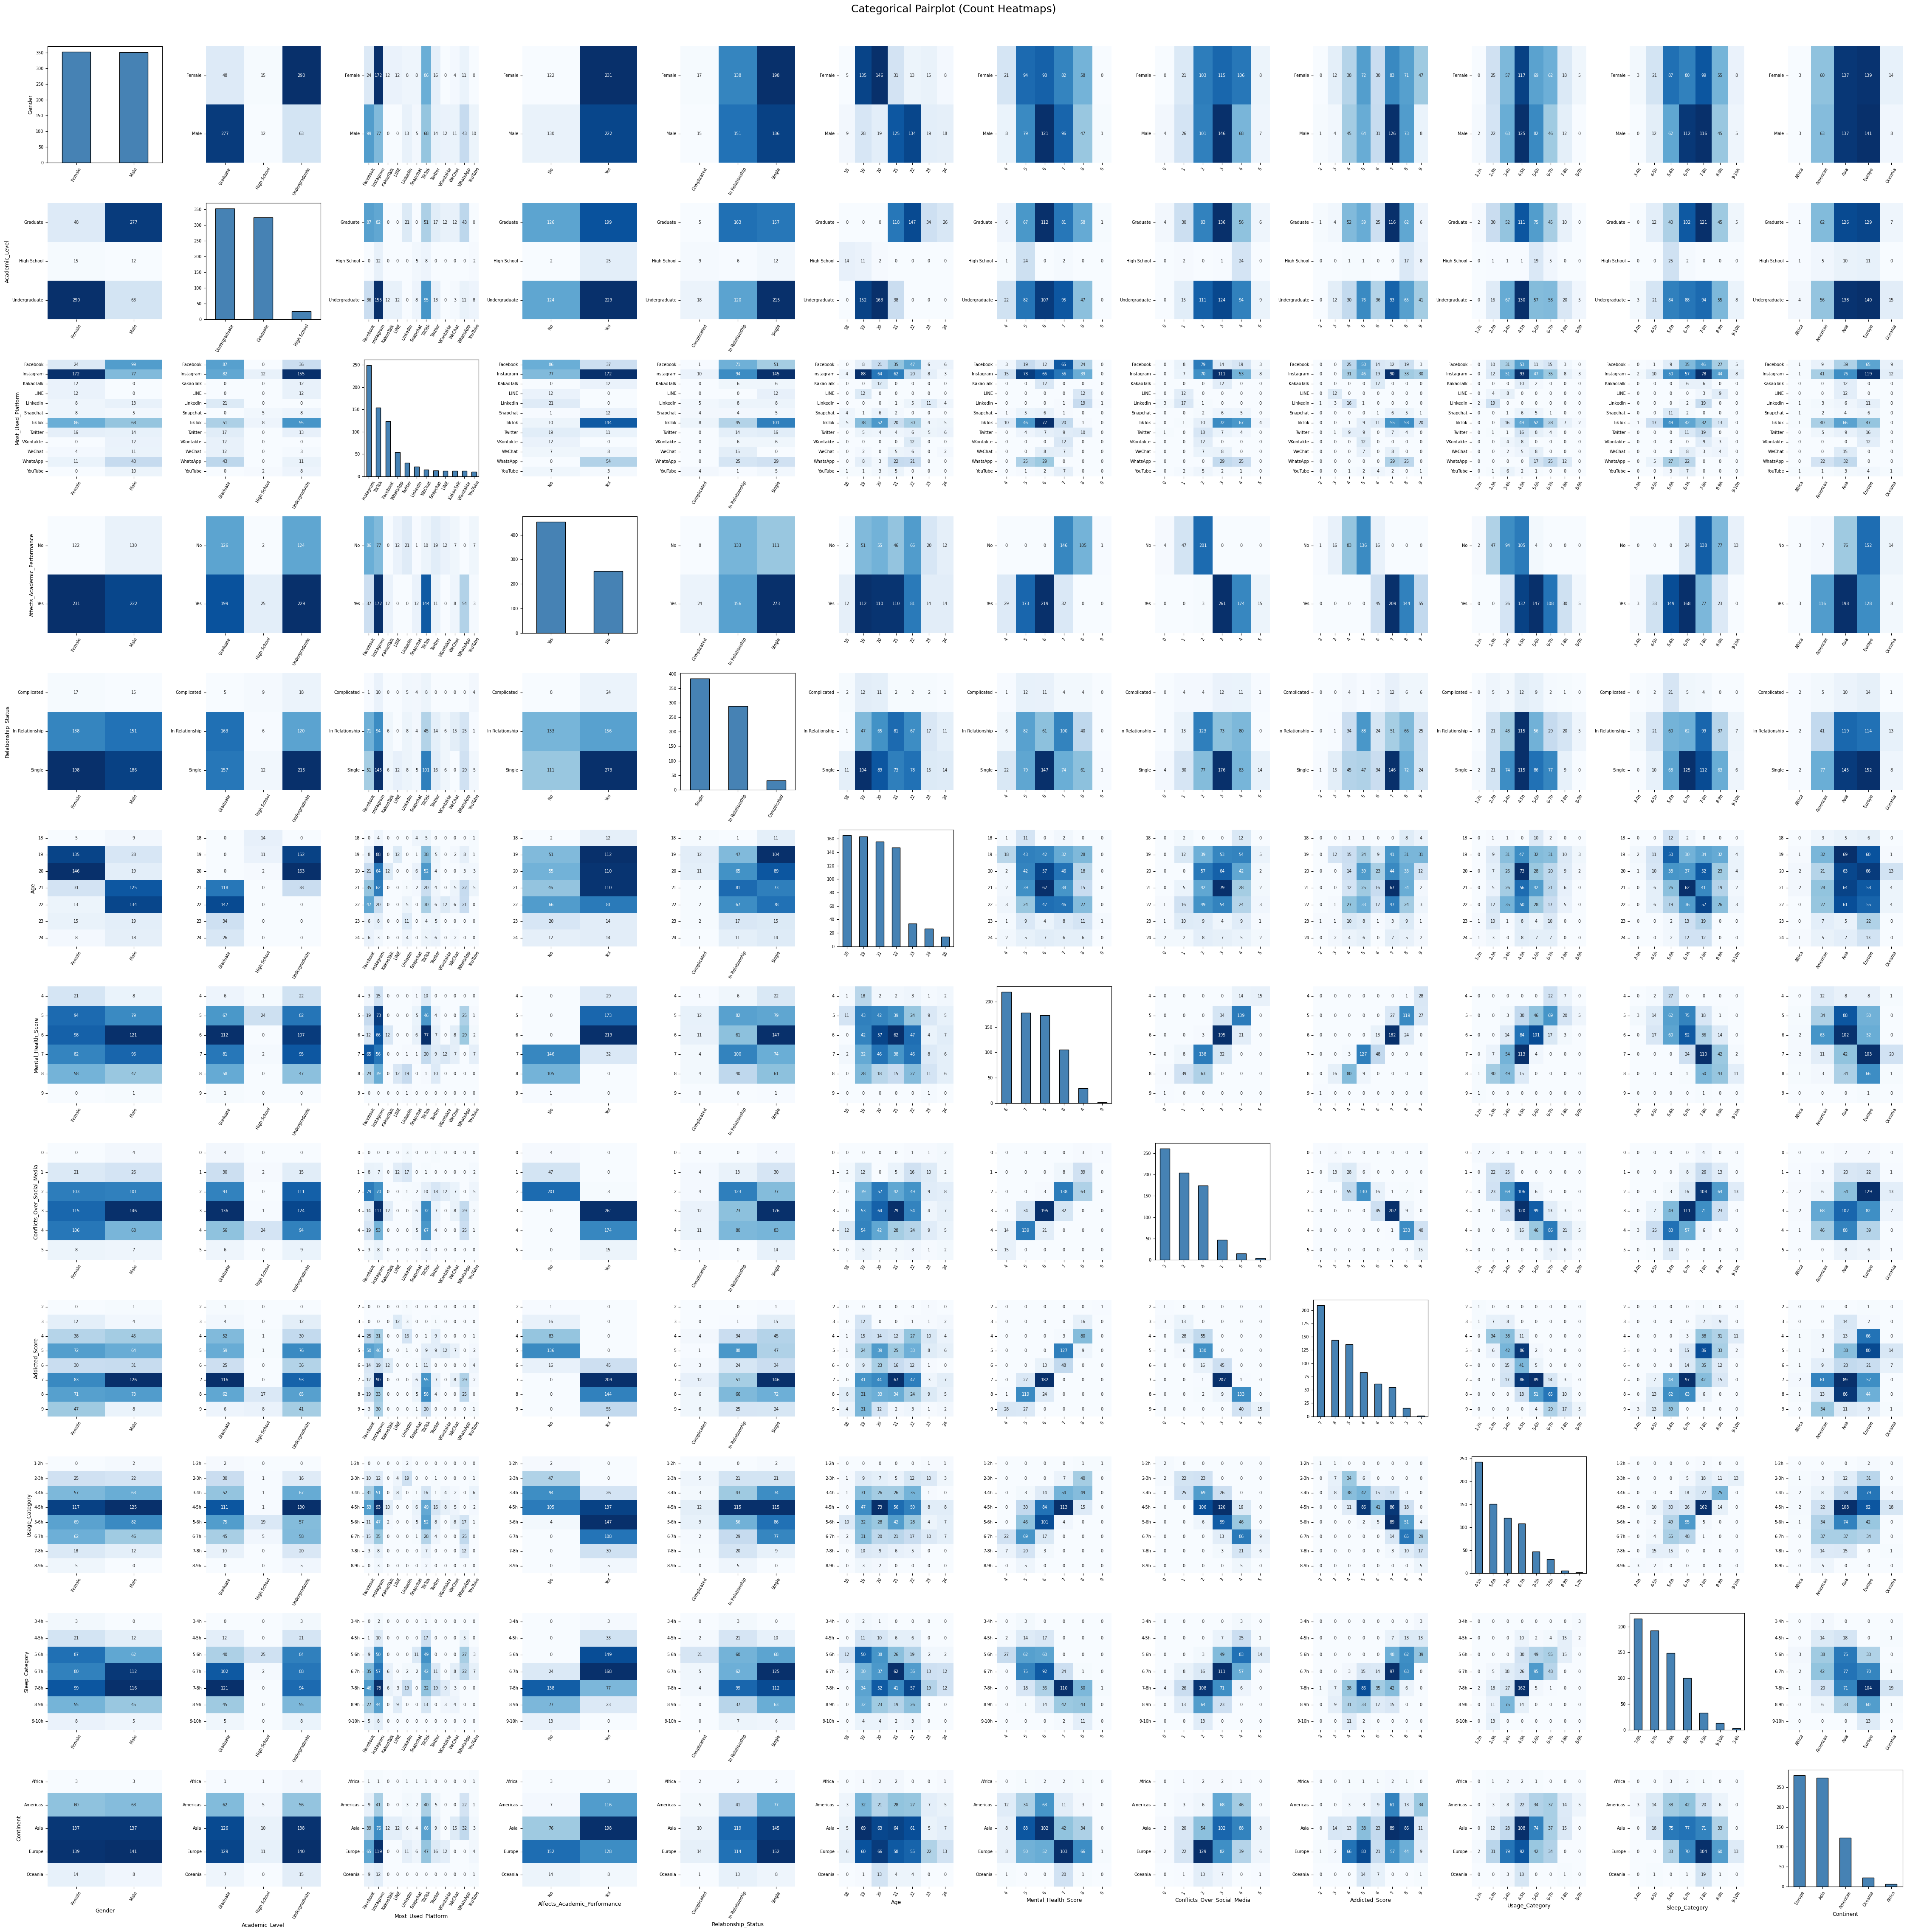

In [12]:
categorical_cols = ['Gender', 'Academic_Level', 
                    'Most_Used_Platform', 'Affects_Academic_Performance', 
                    'Relationship_Status', "Age", 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score', 
                    'Usage_Category', 'Sleep_Category', 'Continent']

n = len(categorical_cols)
fig, axes = plt.subplots(n, n, figsize=(45, 45))

for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        ax = axes[i, j]
        if i == j:
            # Diagonal: show value counts bar
            df[col1].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
            ax.set_xlabel('')
        else:
            # Off-diagonal: heatmap of counts
            ct = pd.crosstab(df[col1], df[col2])
            sns.heatmap(ct, ax=ax, cmap='Blues', cbar=False, annot=True, fmt='d', annot_kws={"size": 7})
        
        # Only show labels on edges
        if i == n - 1:
            ax.set_xlabel(col2, fontsize=9)
        else:
            ax.set_xlabel('')
        if j == 0:
            ax.set_ylabel(col1, fontsize=9)
        else:
            ax.set_ylabel('')
        
        ax.tick_params(axis='x', rotation=60, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle("Categorical Pairplot (Count Heatmaps)", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()